# `digitize_ecg` — Self-Contained Function

This notebook distills the full `process_template.ipynb` pipeline into a single reusable function.

**Goal**: given an image + the parameters discovered via the UI (crop regions, baselines, pixels-per-square), return voltage/time datapoints ready to save as `.npy` — exactly the format the pipeline expects.

The function is written to be **copy-paste ready into the Flask server**, with no external dependencies beyond what the server already imports.

### What the function needs (from the UI steps)
| Parameter | UI Step | Description |
|---|---|---|
| `image` | Step 1 | PIL Image of the raw ECG |
| `crop_regions` | Step 4 | `{'V1': {'x1','y1','x2','y2'}, ...}` in original image pixels |
| `baselines` | Step 2 | `[y_v1, y_v2, y_v3]` y-coords in original image pixels |
| `pixels_per_square` | Step 5 | Calibration: pixels per small ECG square |
| `contrast` | Step 3 | Contrast multiplier (default 1.5) |
| `threshold` | Step 6 | Darkness cutoff for trace detection (default 20) |

In [ ]:
from PIL import Image, ImageDraw, ImageEnhance
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import interp1d

In [ ]:
def resample_to_1000hz(raw_lead: list[tuple[float, float]], sample_rate=1000) -> np.ndarray:
    """
    Resample a list of (time, voltage) pairs to uniform 1000 Hz sampling.
    
    Parameters
    ----------
    raw_lead : list of (time, voltage) tuples
        Raw digitized ECG datapoints
    sample_rate : int
        Target sampling rate in Hz (default 1000)
    
    Returns
    -------
    np.ndarray
        Uniformly sampled voltage values at `sample_rate` Hz
    """
    if len(raw_lead) == 0:
        return np.array([])
    
    # Unzip pairs into two arrays
    times, voltages = zip(*raw_lead)
    times = np.array(times)
    voltages = np.array(voltages)
    
    # Handle duplicate times by keeping unique values
    unique_times, indices = np.unique(times, return_index=True)
    unique_voltages = voltages[indices]
    
    # Add tiny offsets if times are still not strictly increasing
    if not np.all(np.diff(unique_times) > 0):
        unique_times = unique_times + np.arange(len(unique_times)) * 1e-9
    
    # Interpolate to create uniform sampling
    f = interp1d(unique_times, unique_voltages, kind='linear', fill_value='extrapolate')
    start_time = unique_times[0]
    end_time = unique_times[-1]
    
    uniform_times = np.arange(start_time, end_time, 1/sample_rate)
    uniform_voltages = f(uniform_times)
    
    return uniform_voltages

## The Function

### Key design decisions (mirroring `process_template.ipynb`)

1. **Baseline embedding trick**: We draw blue horizontal lines onto a *separate copy* of the image (`ecg_with_baselines`) at the known baseline y-coordinates, *before cropping*. After cropping both images with the same bounds, the blue line lands at exactly the right relative row inside each lead crop — no manual offset math needed.

2. **Two parallel crops per lead**:
   - `lead_crop`: post-contrast, clean image → used to detect the ECG trace (scan for dark pixels)
   - `lead_baselines_crop`: pre-contrast + blue lines → used to detect the baseline row (scan for blue pixels)
   Keeping them separate means the baseline lines never pollute trace detection.

3. **Trace detection — one point per column**: iterating top-to-bottom and `break`ing on the first dark pixel ensures the signal is a function (one voltage per time step), not a blob.

4. **`b < 180` guard**: pure blue pixels (r=0, g=0, b=255) have an RGB average of 85, which already fails the `< threshold` check — but this guard makes the exclusion of any blue artifacts explicit.

5. **Baseline row via `mode`**: the blue line spans the full width, so almost every column contributes the same row. `stats.mode` handles columns where the ECG trace overlaps the baseline line.

In [ ]:
def digitize_ecg(image, crop_regions, baselines, pixels_per_square, contrast=1.5, threshold=50):
    """
    Convert an ECG image to time-series (time, voltage) datapoints for V1, V2, V3,
    then resample to uniform 1000 Hz.

    Parameters
    ----------
    image : PIL.Image
        Raw ECG image (pre-contrast).
    crop_regions : dict
        {'V1': {'x1': int, 'y1': int, 'x2': int, 'y2': int}, 'V2': ..., 'V3': ...}
        All coordinates in original image pixel space.
    baselines : list of int
        [y_v1, y_v2, y_v3] — y-coordinates of each lead's isoelectric baseline
        in original image pixel space.
    pixels_per_square : float
        Calibration value: how many pixels equal one small ECG square.
        1 small square = 0.04 s horizontally = 0.1 mV vertically.
    contrast : float
        Contrast enhancement multiplier applied to the image before detection.
        1.0 = no change. Default 1.5.
    threshold : int
        A pixel is considered part of the ECG trace if its mean RGB value is
        below this value (and it is not a blue baseline pixel). Default 50.

    Returns
    -------
    numpy.ndarray of shape (3,), dtype=object
        Each element is a 1D array of voltage values sampled at 1000 Hz for V1, V2, V3.
    """

    # Embed baselines as blue lines onto a copy of the RAW image.
    ecg_with_baselines = image.copy()
    draw = ImageDraw.Draw(ecg_with_baselines)
    for baseline_y in baselines:
        draw.line((0, baseline_y, image.width, baseline_y), fill='blue', width=1)

    # Apply contrast enhancement to the working image.
    enhancer = ImageEnhance.Contrast(image)
    ecg = enhancer.enhance(contrast)

    lead_names = ['V1', 'V2', 'V3']
    all_resampled = []

    for lead_name in lead_names:
        region = crop_regions[lead_name]
        x1, y1, x2, y2 = region['x1'], region['y1'], region['x2'], region['y2']

        # Crop both images with the same bounds.
        lead_crop          = ecg.crop((x1, y1, x2, y2))
        lead_baselines_crop = ecg_with_baselines.crop((x1, y1, x2, y2))

        cv_image     = np.array(lead_crop.convert('RGB'))
        cv_baselines = np.array(lead_baselines_crop.convert('RGB'))
        height, width, _ = cv_image.shape

        # Detect the baseline row from the baselines copy.
        blues = []
        for col in range(width):
            for row in range(height):
                r, g, b = cv_baselines[row][col]
                if int(b) > 100 and int(r) < 100 and int(g) < 100:
                    blues.append(row)
                    break

        if len(blues) == 0:
            print(f"[WARNING] No baseline detected for {lead_name} — using image midpoint")
            baseline_row = height // 2
        else:
            baseline_row = int(stats.mode(blues).mode)

        # Detect the ECG trace from the clean, contrast-enhanced crop.
        raw_points = []
        for col in range(width):
            for row in range(height):
                r, g, b = cv_image[row][col]
                if (int(r) + int(g) + int(b)) / 3 < threshold and b < 180:
                    raw_points.append((col, row))
                    break

        # Convert pixel coordinates → (time_s, voltage_mV).
        datapoints = []
        for col, row in raw_points:
            time    = col * (1 / pixels_per_square) * 0.04
            voltage = (baseline_row - row) * (1 / pixels_per_square) * 0.1
            datapoints.append((time, voltage))

        # Resample to uniform 1000 Hz
        resampled_voltages = resample_to_1000hz(datapoints, sample_rate=1000)
        
        print(f"{lead_name}: {len(datapoints)} raw points → {len(resampled_voltages)} samples @ 1000 Hz")
        all_resampled.append(resampled_voltages)

    return np.array(all_resampled, dtype=object)

---
## Usage

Fill in the parameters below — these are exactly what the UI collects across steps 1–5.

In [22]:
# ── Step 1: Load image ────────────────────────────────────────────────
image = Image.open('ecg.png')  # or 'ecg_edited.png' if manually cleaned

# ── Step 2: Baselines (y-coordinates in original image pixel space) ───
baselines = [74, 195, 316]  # [y_V1, y_V2, y_V3]

# ── Step 3: Contrast ──────────────────────────────────────────────────
contrast = 1.5

# ── Step 4: Crop regions (original image pixel space) ────────────────
crop_regions = {
    'V1': {'x1': 506, 'y1': 41, 'x2': 713, 'y2': 136},
    'V2': {'x1': 503, 'y1': 166, 'x2': 727, 'y2': 269},
    'V3': {'x1': 504, 'y1': 285, 'x2': 723, 'y2': 406},
}

# ── Step 5: Calibration ───────────────────────────────────────────────
pixels_per_square = 3.85  # pixels per small ECG square

# ── Optional: trace detection sensitivity ─────────────────────────────
threshold = 50  # lower = only detect very dark pixels

In [23]:
datapoints = digitize_ecg(
    image=image,
    crop_regions=crop_regions,
    baselines=baselines,
    pixels_per_square=pixels_per_square,
    contrast=contrast,
    threshold=threshold,
)

V1: 106 points detected, baseline row = 33
V2: 128 points detected, baseline row = 29
V3: 133 points detected, baseline row = 31


## Plot

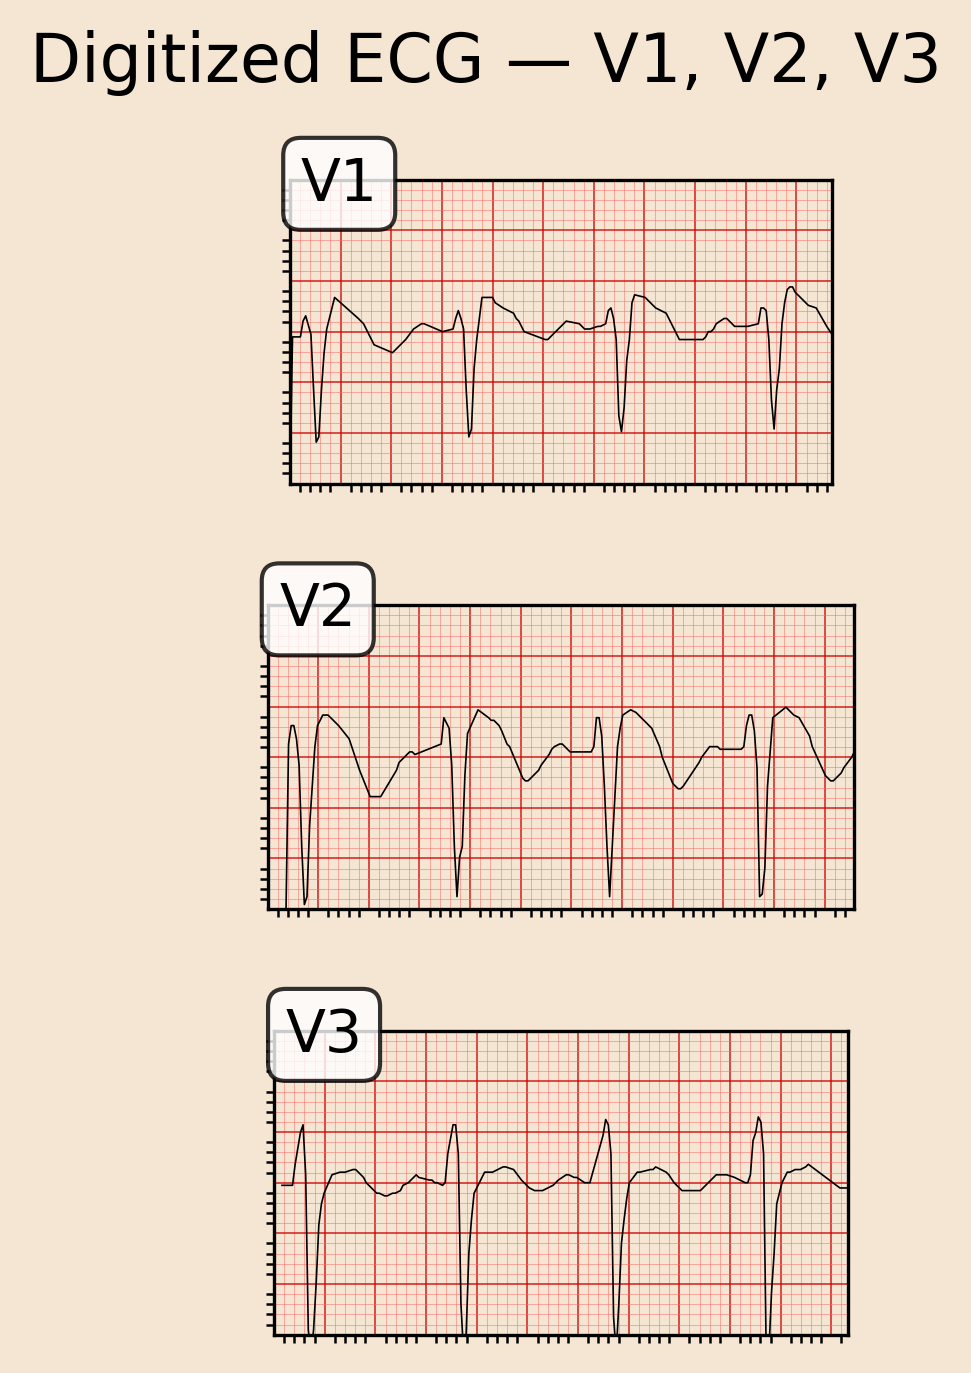

In [ ]:
from matplotlib.ticker import MultipleLocator

lead_names = ['V1', 'V2', 'V3']
num_leads = len(lead_names)

fig, axs = plt.subplots(num_leads, 1, figsize=(20, 5), dpi=300)
fig.suptitle('Digitized ECG — V1, V2, V3 (1000 Hz)', fontsize=16)
fig.patch.set_facecolor('#F5E6D3')

if num_leads == 1:
    axs = [axs]

for ax, lead_name, voltages in zip(axs, lead_names, datapoints):
    ax.set_facecolor('#F5E6D3')

    ax.text(0.02, 1.08, lead_name, transform=ax.transAxes,
            fontsize=14, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    if len(voltages) == 0:
        ax.text(0.5, 0.5, f'{lead_name}: no data', ha='center', va='center',
                transform=ax.transAxes)
        continue

    # Generate time axis for 1000 Hz sampling
    times = np.arange(len(voltages)) / 1000.0  # Convert sample index to seconds

    ax.set_ylim(-1.5, 1.5)
    ax.set_xlim(0, max(times) if len(times) > 0 else 5)

    ax.xaxis.set_major_locator(MultipleLocator(0.2))
    ax.xaxis.set_minor_locator(MultipleLocator(0.04))
    ax.yaxis.set_major_locator(MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(MultipleLocator(0.1))

    ax.grid(which='major', axis='x', linewidth=0.4, color='#CC0000', alpha=0.8)
    ax.grid(which='minor', axis='x', linewidth=0.2, color='#FF6666', alpha=0.6)
    ax.grid(which='major', axis='y', linewidth=0.4, color='#CC0000', alpha=0.8)
    ax.grid(which='minor', axis='y', linewidth=0.2, color='#FF6666', alpha=0.6)

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(left=False, bottom=False)

    ax.set_aspect(0.04 / 0.1, adjustable='box')
    ax.plot(times, voltages, linewidth=0.4, color='black')

plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()

## Save as `.npy`

The output format matches what `extract_features.py` expects: a 1-D object array of length 3, where each element is a list of `(time, voltage)` tuples.

In [16]:
filename = '001.npy'  # change as needed
np.save(filename, datapoints)
print(f"Saved to {filename}  |  shape: {datapoints.shape}")

# Verify round-trip
loaded = np.load(filename, allow_pickle=True)
print(f"V1 points: {len(loaded[0])}, V2 points: {len(loaded[1])}, V3 points: {len(loaded[2])}")

Saved to 001.npy  |  shape: (3,)
V1 points: 181, V2 points: 130, V3 points: 128
